<a href="https://colab.research.google.com/github/Jyoti-Yadav2/R-for-bioinformatics/blob/main/Microarray_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#install R base
#configure rpy2

In [2]:
install.packages("BiocManager")
BiocManager::install("preprocessCore",
                     configure.args = c(preprocessCore = "--disable-threading"),
                     force = TRUE,
                     type = "source")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Installing package(s) 'preprocessCore'

Old packages: 'callr', 'dbplyr', 'diffobj', 'httr2', 'MASS', 'openssl', 'pak',
  'pkgdown', 'pkgload', 'Rcpp', 'rlang', 'rstudioapi', 'selectr',
  'sessioninfo', 'shiny', 'survival', 'tinytex', 'urlchecker', 'withr', 'xfun',
  'xml2', 'xtable', 'zip', 'nlme'



In [3]:
BiocManager::install(c("affy", "limma","Biobase"),
                      update=FALSE, force=TRUE)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Installing package(s) 'affy', 'limma', 'Biobase'



In [4]:
BiocManager::install(c("hgu133a2cdf", "hgu133a2.db",
                       "marray", "hgu133a2probe"),
                       update=FALSE, force=TRUE)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Installing package(s) 'hgu133a2cdf', 'hgu133a2.db', 'marray', 'hgu133a2probe'



In [5]:
library(affy)
library(hgu133a2cdf)
library(hgu133a2probe)

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: Biobase

Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Bioba

Data Import

In [6]:
untar("GSE110332_RAW.tar")

In [7]:
#getwd()
dir(pattern="*.cel")
list.files()

character(0)

[1] "affy_all.xls"            "affy_targets.txt"       
 [3] "GSE110332_RAW.tar"       "GSM2987594_SAD13.CEL.gz"
 [5] "GSM2987595_SAD14.CEL.gz" "GSM2987596_SAD15.CEL.gz"
 [7] "GSM2987597_SAD16.CEL.gz" "GSM2987598_SAD17.CEL.gz"
 [9] "GSM2987599_SAD18.CEL.gz" "hgbreastcancerQC_Report"
[11] "lim"                     "my_annot_file.xls"      
[13] "my_file.xls"             "sample_data"

.**cdf** (Chip Definition File) and .**probe** packages act as the map and coordinates for translating the raw, physical signals from an Affymetrix .CEL file into actual gene identities.

In [8]:
hgu133a2probe[1:3, 1:4]

,sequence,x,y,Probe.Set.Name
,<I<chr>>,<int>,<int>,<I<chr>>
1,CACCCAGCTGGTCCTGTGGATGGGA,416,177,1007_s_at
2,GCCCCACTGGACAACACTGATTCCT,569,289,1007_s_at
3,TGGACCCCACTGGCTGAGAATCTGG,299,537,1007_s_at


In [9]:
mydata <- ReadAffy(filenames = list.celfiles())
mydata

AffyBatch object
size of arrays=732x732 features (20 kb)
cdf=HG-U133A_2 (22277 affyids)
number of samples=6
number of genes=22277
annotation=hgu133a2
notes=

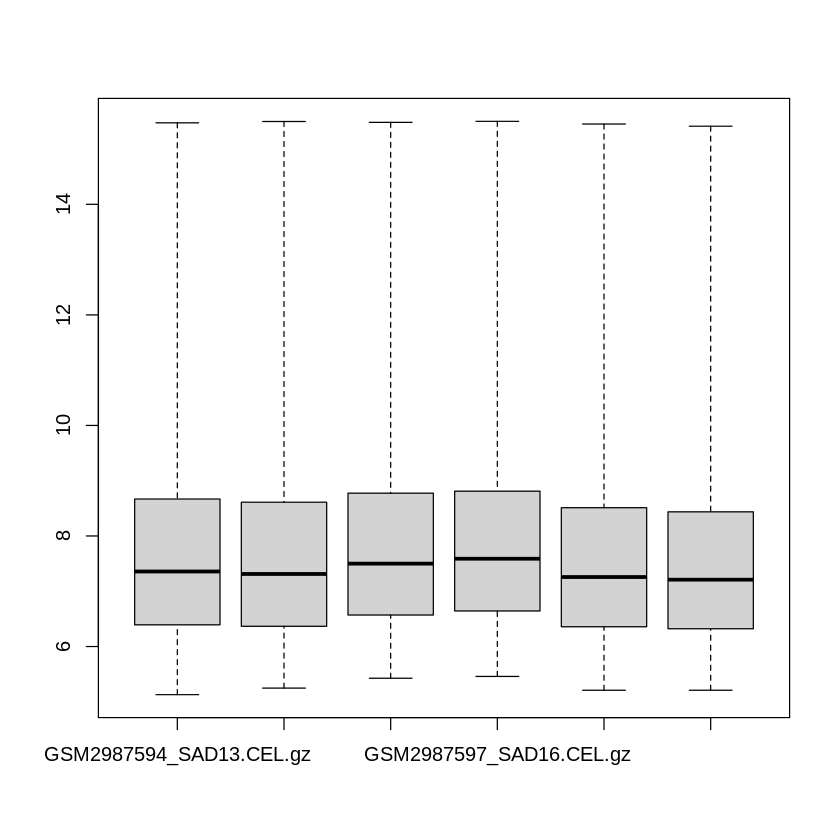

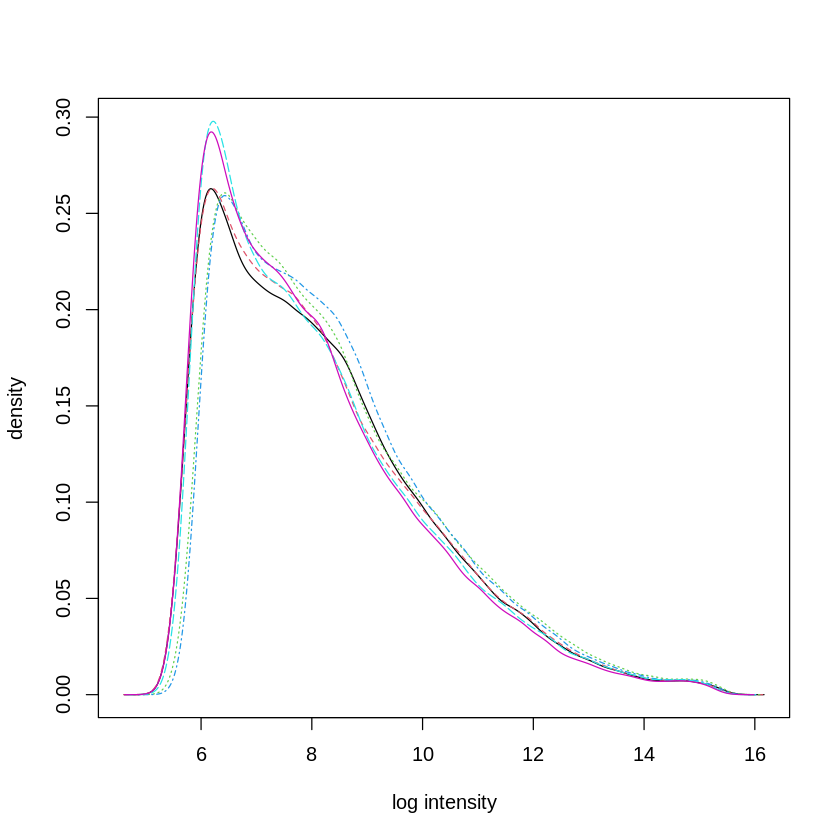

In [10]:
boxplot(mydata)
hist(mydata)

Normalization

In [11]:
# Restrict backend linear algebra threading pools
Sys.setenv(OMP_NUM_THREADS = "1")
Sys.setenv(MKL_NUM_THREADS = "1")
Sys.setenv(OPENBLAS_NUM_THREADS = "1")

eset_rma <- rma(mydata)
eset_rma[1:4, 1:2]

Background correcting
Normalizing
Calculating Expression


ExpressionSet (storageMode: lockedEnvironment)
assayData: 4 features, 2 samples 
  element names: exprs 
protocolData
  sampleNames: GSM2987594_SAD13.CEL.gz GSM2987595_SAD14.CEL.gz
  varLabels: ScanDate
  varMetadata: labelDescription
phenoData
  sampleNames: GSM2987594_SAD13.CEL.gz GSM2987595_SAD14.CEL.gz
  varLabels: sample
  varMetadata: labelDescription
featureData: none
experimentData: use 'experimentData(object)'
Annotation: hgu133a2 

In [13]:
mydf <- 2^exprs(eset_rma)

# The 'INDEX' vector for tapply must have the same length as the data vector.
# `mydf` contains data for 6 samples (from the 6 CEL files), so `colnames(mydf)` has a length of 6.
# Using `rep(1:3, each=2)` as a placeholder to group the 6 samples into 3 groups of 2.
myList <- tapply(colnames(mydf), rep(1:3, each=2), list)
names(myList) <- sapply(myList, paste, collapse="_")
mymean <- sapply(myList, function(x) rowMeans(mydf[,x, drop=FALSE]))
mymean [1:2, 1:2]

,GSM2987594_SAD13.CEL.gz_GSM2987595_SAD14.CEL.gz,GSM2987596_SAD15.CEL.gz_GSM2987597_SAD16.CEL.gz
1007_s_at,671.2540,641.9286
1053_at,517.0459,538.8891


Present,Marginal and Absent Calls

In [14]:
eset_pma <- mas5calls(mydata)

Getting probe level data...
Computing p-values
Making P/M/A Calls


In [15]:
my_frame <- data.frame(exprs(eset_rma), exprs(eset_pma),
                       assayDataElement(eset_pma, "se.exprs"))
my_frame <- my_frame[, sort(names(my_frame))]
my_frame[1:2, 1:2]
write.table(my_frame, file="my_file.xls", sep="\t", col.names = NA)

,GSM2987594_SAD13.CEL.gz,GSM2987594_SAD13.CEL.gz.1
,<dbl>,<chr>
1007_s_at,9.344246,P
1053_at,9.009020,P


Add Annotation Information

In [16]:
library("hgu133a2.db") #loads required annotation package
Annot <- data.frame(ACCNUM=sapply(as.list(hgu133a2ACCNUM), paste, collapse=", "),
                    SYMBOL=sapply(as.list(hgu133a2SYMBOL), paste, collapse=", "),
                    DESC=sapply(as.list(hgu133a2GENENAME), paste, collapse=", "))
Annot[3:4,]

Loading required package: org.Hs.eg.db







,ACCNUM,SYMBOL,DESC
,<chr>,<chr>,<chr>
117_at,X51757,HSPA6,heat shock protein family A (Hsp70) member 6
121_at,X69699,PAX8,paired box 8


In [17]:
#Merge annotations with expression data
all <- merge(Annot, my_frame, by.x=0, by.y=0, all=T)
#Export data to text file that can be imported into Excel
write.table(all, file="my_annot_file.xls", sep="\t", col.names = NA)

Clustering Tree for Samples

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



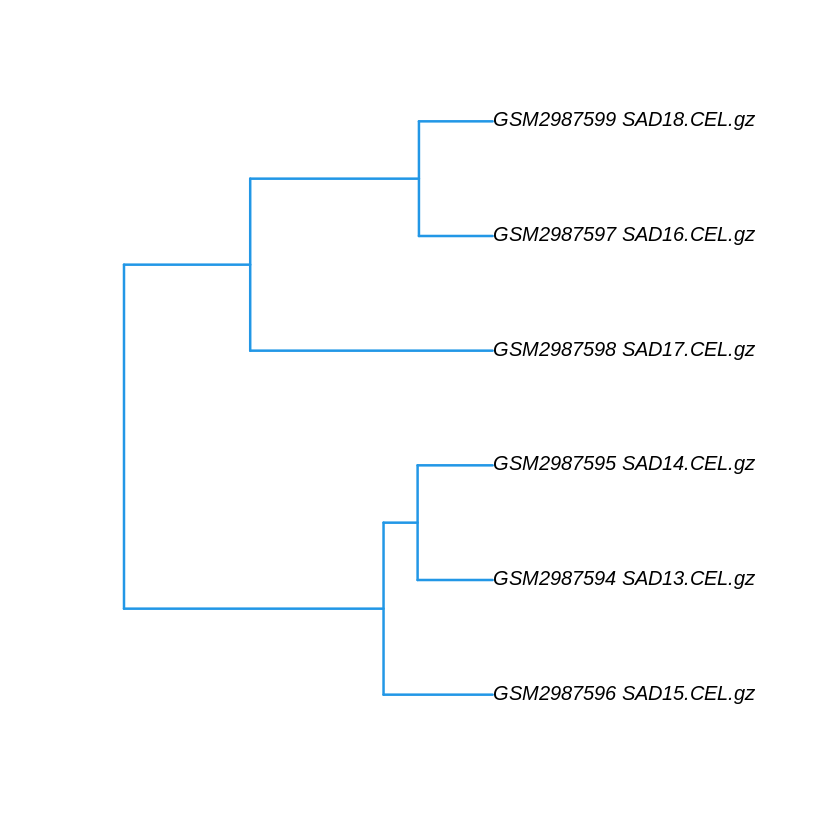

In [18]:
install.packages("ape")
library(ape)
d <- cor(2^exprs(eset_rma), method="pearson")
hc <- hclust(dist(1-d))
plot.phylo(as.phylo(hc), type="p", edge.col=4, edge.width=2,
                    show.node.label=TRUE)

Quality Report

In [19]:
BiocManager::install("arrayQualityMetrics", update=FALSE, force=TRUE)
library(arrayQualityMetrics)

arrayQualityMetrics(expressionset = mydata,
                    outdir = "hgbreastcancerQC_Report", force = TRUE,
                    do.logtransform = TRUE)

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Installing package(s) 'arrayQualityMetrics'

The report will be written into directory 'hgbreastcancerQC_Report'. 

Warning message in svgStyleAttributes(style, svgdev):
“Removing non-SVG style attribute name(s): subscripts, group.number, group.value”
Warning message in svgStyleAttributes(style, svgdev):
“Removing non-SVG style attribute name(s): subscripts, group.number, group.value”
Warning message in svgStyleAttributes(style, svgdev):
“Removing non-SVG style attribute name(s): subscripts, group.number, group.value”
Warning message in svgStyleAttributes(style, svgdev):
“Removing non-SVG style attribute name(s): subscripts, group.number, group.value”
Warning message in svgStyleAttributes(style, svgdev):
“Removing non-SVG styl

Analysis of DEGs with limma

In [20]:
library(limma)

# List of CEL filenames
filenames <- c(
  "GSM2987594_SAD13.CEL.gz",
  "GSM2987595_SAD14.CEL.gz",
  "GSM2987596_SAD15.CEL.gz",
  "GSM2987597_SAD16.CEL.gz",
  "GSM2987598_SAD17.CEL.gz",
  "GSM2987599_SAD18.CEL.gz"
)

# Create a data frame for targets with a placeholder 'Target' column
targets_df <- data.frame(
  FileName = filenames,
  Target = c(rep("Group1", 3), rep("Group2", 3)),
  # Example: 3 samples for Group1, 3 for Group2
  stringsAsFactors = FALSE
)

# Write the targets data frame to 'affy_targets.txt'
write.table(targets_df, file = "affy_targets.txt", sep = "\t", quote = FALSE,
            row.names = FALSE)

targets <- readTargets("affy_targets.txt")
data <- ReadAffy(filenames=targets$FileName)
eset <- rma(data)


Attaching package: ‘limma’


The following object is masked from ‘package:BiocGenerics’:

    plotMA




Background correcting
Normalizing
Calculating Expression


In [21]:
##RMA/GCRMA generate log2 values and MAS5 produces absolute values
#exprs(eset) <- log2(exprs(eset))
pData(eset) #lists analysed file names

write.exprs(eset, file="affy_all.xls")

,sample
,<int>
GSM2987594_SAD13.CEL.gz,1
GSM2987595_SAD14.CEL.gz,2
GSM2987596_SAD15.CEL.gz,3
GSM2987597_SAD16.CEL.gz,4
GSM2987598_SAD17.CEL.gz,5
GSM2987599_SAD18.CEL.gz,6


In [22]:
#set up design and contrast matrices
design <- model.matrix(~ -1+factor(c(1,1,2,2,3,3)))
colnames(design) <- c("group1", "group2", "group3") # Corrected to 3 column names
design[1:2,]

,group1,group2,group3
1,1,0,0
2,1,0,0


In [23]:
# Fit a linear model for each gene based on the given series of arrays.
fit <- lmFit(eset, design)
## Creates appropriate contrast matrix to perform all pairwise comparisons.
contrast.matrix <- makeContrasts(group2-group1, group3-group2, group3-group1, levels=design)
contrast.matrix

,group2 - group1,group3 - group2,group3 - group1
group1,-1,0,-1
group2,1,-1,0
group3,0,1,1


In [24]:
fit2 <- contrasts.fit(fit, contrast.matrix)
fit2 <- eBayes(fit2)

In [25]:
tmp <- topTable(fit2, coef=1, adjust="fdr", sort.by="B", number=3)
tmp

,logFC,AveExpr,t,P.Value,adj.P.Val,B
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
221276_s_at,-0.6409258,4.814662,-7.449633,0.0001014473,0.9039512,-2.620614
209583_s_at,0.5889388,3.806326,6.076016,0.0003845120,0.9039512,-2.789257
207101_at,0.5280865,5.454246,5.983120,0.0004240097,0.9039512,-2.803738


In [26]:
write.table(topTable(fit2, coef=1, adjust="fdr", sort.by="B", number=Inf), file="lim")

GO term Enrichment Analysis with GOstats

In [27]:
library(hgu133a2.db)
BiocManager::install(("GOstats"), force = TRUE)
library(GOstats)

#Create two sets, one that consists of all the genes in the data and the other that consists of DE genes, as follows:
all_genes <- rownames(eset)
sel_genes <- rownames(tmp)

# Map these sets to their Entrez IDs using hgu133a2.db
all_genes <- unique(na.omit(unlist(mget(all_genes, hgu133a2ENTREZID, ifnotfound=NA))))
sel_genes <- unique(na.omit(unlist(mget(sel_genes, hgu133a2ENTREZID, ifnotfound=NA))))

# Now, define a cutoff for the test statistics as follows:
hgCutoff <- 0.5
#GOHyperGParams object that will be used as an input parameter for the enrichment computations.
#It can be computed with the following function:
params <- new("GOHyperGParams", geneIds=sel_genes, universeGeneIds= all_genes,
              annotation="hgu133a2.db", ontology="BP", pvalueCutoff=hgCutoff,
              conditional=FALSE, testDirection="over")

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.rstudio.com

Bioconductor version 3.23 (BiocManager 1.30.27), R 4.6.0 (2026-04-24)

Installing package(s) 'GOstats'

Old packages: 'callr', 'dbplyr', 'diffobj', 'httr2', 'MASS', 'openssl', 'pak',
  'pkgdown', 'pkgload', 'Rcpp', 'rlang', 'rstudioapi', 'selectr',
  'sessioninfo', 'shiny', 'survival', 'tinytex', 'urlchecker', 'withr', 'xfun',
  'xml2', 'xtable', 'zip', 'nlme'

Loading required package: Category

Loading required package: Matrix


Attaching package: ‘Matrix’


The following object is masked from ‘package:S4Vectors’:

    expand


Loading required package: graph


Attaching package: ‘graph’


The following objects are masked from ‘package:ape’:

    complement, degree, edges





Attaching package: ‘GOstats’


The following object is masked from ‘package:AnnotationDbi’:

    makeGOGraph




In [28]:
# hypergeometric test to get the p-value for the GO annotations as follows:
hgOver <- hyperGTest(params) # Check the summary of the object that was created by typing the following command:
summary(hgOver)[c(3,7),c(1,2,5:7)]

,GOBPID,Pvalue,Count,Size,Term
,<chr>,<dbl>,<int>,<int>,<chr>
3,GO:1905522,0.001541756,1,6,negative regulation of macrophage migration
7,GO:0150079,0.003081926,1,12,negative regulation of neuroinflammatory response


Venn diagram for DEG Sets

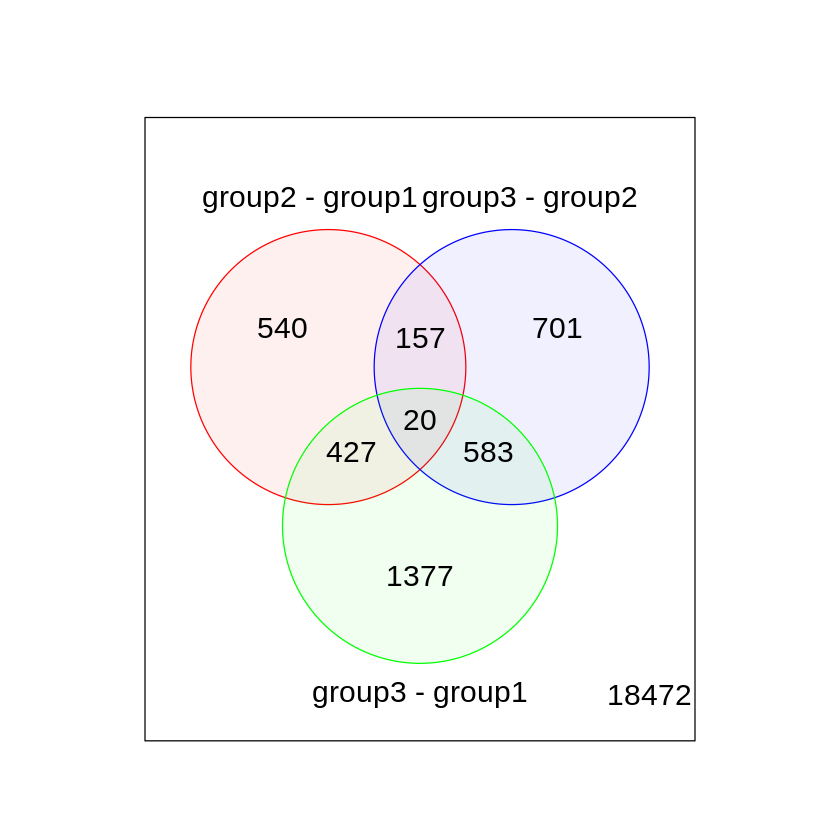

In [29]:
# 1. Classify genes as significantly up (1), down (-1), or not significant (0)
# Adjust p.value and lfc (log fold change) thresholds as needed
results <- decideTests(fit2, adjust.method = "none", p.value = 0.05)
# 2. Plot the Venn diagram automatically for all 3 contrasts
vennDiagram(results,
            include = "both", # Can be "up", "down", or "both"
            mar = c(1, 1, 1, 1),
            circle.col = c("red", "blue", "green"))

In [30]:
# Extract gene names for each individual contrast (where status is not 0)
deg_c1 <- rownames(fit2)[results[, "group2 - group1"] != 0]
deg_c2 <- rownames(fit2)[results[, "group3 - group2"] != 0]
deg_c3 <- rownames(fit2)[results[, "group3 - group1"] != 0] # Find the intersection common to ALL three contrasts
common_degs <- intersect(intersect(deg_c1, deg_c2), deg_c3)
# Print the number of common genes
cat("Number of genes common to all contrasts:",
    length(common_degs), "\n")

Number of genes common to all contrasts: 20 
